# Preliminary round 02: CatBoost with date/time, season and product-size features

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import catboost as cb
import lightgbm as lgb
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)

## Load Data

In [95]:
train_df = pd.read_csv("dataset/train_df.csv")
train_df["order_delivered_timestamp"] = pd.to_datetime(train_df["order_delivered_timestamp"])
train_df["order_purchase_timestamp"] = pd.to_datetime(train_df["order_purchase_timestamp"])
train_df["order_approved_at"] = pd.to_datetime(train_df["order_approved_at"])
train_df["order_estimated_delivery_date"] = pd.to_datetime(train_df["order_estimated_delivery_date"])

test_df = pd.read_csv("dataset/test_merged_df.csv")
test_df["order_delivered_timestamp"] = pd.to_datetime(test_df["order_delivered_timestamp"])
test_df["order_purchase_timestamp"] = pd.to_datetime(test_df["order_purchase_timestamp"])
test_df["order_approved_at"] = pd.to_datetime(test_df["order_approved_at"])
test_df["order_estimated_delivery_date"] = pd.to_datetime(test_df["order_estimated_delivery_date"])

train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_late
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,1,credit_card,1,259.14,toys,491.0,19.0,12.0,16.0,0
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,1,credit_card,8,382.39,watches_gifts,440.0,18.0,14.0,17.0,0
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,1,credit_card,4,249.25,costruction_tools_garden,2200.0,16.0,16.0,16.0,0
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,1,credit_card,2,27.79,toys,1450.0,68.0,3.0,48.0,0
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,1,credit_card,1,76.15,toys,300.0,17.0,4.0,12.0,0


## Feature Engineering

In [96]:
def create_feature(df):
    df = df.copy()

    df["order_purchase_month"] = df["order_purchase_timestamp"].dt.month
    df["order_purchase_day"] = df["order_purchase_timestamp"].dt.day
    df["order_purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek
    df["order_purchase_hour"] = df["order_purchase_timestamp"].dt.hour
    df["order_purchase_week"] = df["order_purchase_timestamp"].dt.isocalendar().week

    df["order_approved_month"] = df["order_approved_at"].dt.month
    df["order_approved_day"] = df["order_approved_at"].dt.day
    df["order_approved_dayofweek"] = df["order_approved_at"].dt.dayofweek
    df["order_approved_hour"] = df["order_approved_at"].dt.hour
    df["order_approved_week"] = df["order_approved_at"].dt.isocalendar().week
    df["deliver_diff"] = (df["order_delivered_timestamp"] - df["order_purchase_timestamp"]).dt.days
    df["estimated_diff"] = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.days
    
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'

    df['season'] = df['order_purchase_month'].apply(get_season)

    df['product_volume'] = df["product_width_cm"] * df["product_length_cm"] * df[
        "product_height_cm"]
    df['product_weight_ratio'] = df["product_weight_g"] / df["product_volume"]

    

    return df

In [97]:
train_df = create_feature(train_df)
train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_late,order_purchase_month,order_purchase_day,order_purchase_dayofweek,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,deliver_diff,estimated_diff,season,product_volume,product_weight_ratio
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,1,credit_card,1,259.14,toys,491.0,19.0,12.0,16.0,0,10,22,6,18,42,10.0,22.0,6.0,19.0,42,4,17,Fall,3648.0,0.134594
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,1,credit_card,8,382.39,watches_gifts,440.0,18.0,14.0,17.0,0,6,20,2,21,25,6.0,20.0,2.0,22.0,25,13,33,Summer,4284.0,0.102708
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,1,credit_card,4,249.25,costruction_tools_garden,2200.0,16.0,16.0,16.0,0,2,16,4,16,7,2.0,17.0,5.0,16.0,7,10,19,Winter,4096.0,0.537109
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,1,credit_card,2,27.79,toys,1450.0,68.0,3.0,48.0,0,8,18,5,18,33,8.0,18.0,5.0,18.0,33,9,31,Summer,9792.0,0.148080
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,1,credit_card,1,76.15,toys,300.0,17.0,4.0,12.0,0,12,22,4,16,51,12.0,22.0,4.0,17.0,51,14,26,Winter,816.0,0.367647


In [98]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87427 entries, 0 to 87426
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       87427 non-null  object        
 1   customer_id                    87427 non-null  object        
 2   order_status                   87427 non-null  object        
 3   order_purchase_timestamp       87427 non-null  datetime64[ns]
 4   order_approved_at              87418 non-null  datetime64[ns]
 5   order_delivered_timestamp      87427 non-null  datetime64[ns]
 6   order_estimated_delivery_date  87427 non-null  datetime64[ns]
 7   customer_zip_code_prefix       87427 non-null  int64         
 8   customer_city                  87427 non-null  object        
 9   customer_state                 87427 non-null  object        
 10  product_id                     87427 non-null  object        
 11  seller_id      

In [99]:
cat_cols = [
    "customer_city",
    "customer_state",
    "payment_type",
    "product_category_name",
    "product_id",
    "seller_id",
    "season",
    "payment_installments",
]

## Baseline

In [100]:
train_df.dropna(subset=["order_approved_at"], inplace=True)
train_df.loc[train_df.product_category_name.isnull(), "product_category_name"] = "unknown"
train_df.shape

(87418, 39)

In [101]:
tmp_df = train_df.drop([
    "order_id",
    "customer_id",
    "order_status",
    "order_delivered_timestamp",
    "order_estimated_delivery_date",
    "customer_zip_code_prefix",
    "payment_sequential",
], axis=1).copy()

X = tmp_df.drop([
    "is_late",
], axis=1)
y = tmp_df["is_late"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((69934, 31), (17484, 31), (69934,), (17484,))

In [102]:
X_train.head()

,order_purchase_timestamp,order_approved_at,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_purchase_month,order_purchase_day,order_purchase_dayofweek,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,deliver_diff,estimated_diff,season,product_volume,product_weight_ratio
85409,2018-07-25 13:54:32,2018-07-25 14:05:40,cuiaba,MT,Gvk6GWtgVh4r,wdkFVpIzRNT3,125.46,111.47,credit_card,2,22.86,toys,887.0,30.0,22.0,20.0,7,25,2,13,30,7.0,25.0,2.0,14.0,30,9,25,Summer,13200.0,0.067197
62573,2018-03-07 07:22:40,2018-03-07 08:00:25,sao paulo,SP,A3aFwBLEhZ43,yWUu6WhwFUAg,257.60,12.28,credit_card,2,781.74,toys,450.0,21.0,27.0,15.0,3,7,2,7,10,3.0,7.0,2.0,8.0,10,20,21,Spring,8505.0,0.052910
60224,2017-08-10 18:56:44,2017-08-12 02:45:12,goiania,GO,QnvE5E4vp0FY,pgoh0nDV1Ho5,26.85,29.31,wallet,1,220.08,cool_stuff,420.0,26.0,12.0,21.0,8,10,3,18,32,8.0,12.0,5.0,2.0,32,5,14,Summer,6552.0,0.064103
48371,2017-07-20 18:55:51,2017-07-21 02:45:49,rio de janeiro,RJ,5eEOa2yby5uS,NwPn61VaD1X6,1129.99,9.96,wallet,1,164.44,toys,1417.0,19.0,19.0,19.0,7,20,3,18,29,7.0,21.0,4.0,2.0,29,5,21,Summer,6859.0,0.206590
32188,2017-12-14 12:43:26,2017-12-14 12:53:42,macau,RN,3AJd0h2sh8S8,WjEwhmsH2ERN,9.57,33.46,credit_card,10,48.70,toys,17600.0,49.0,49.0,23.0,12,14,3,12,50,12.0,14.0,3.0,12.0,50,42,46,Winter,55223.0,0.318708


In [103]:
y_train.value_counts()

0    64544
1     5390
Name: is_late, dtype: int64

In [104]:
from sklearn.utils import compute_class_weight

cbc_model = cb.CatBoostClassifier(
    cat_features=cat_cols,
    eval_metric='Accuracy',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=200,
    verbose=100,
    random_seed=42,
)
cbc_model.fit(X_train, y_train, eval_set=(X_val, y_val))

Learning rate set to 0.049628
0:	learn: 0.9727743	test: 0.9729467	best: 0.9729467 (0)	total: 26.1ms	remaining: 26.1s
100:	learn: 0.9943661	test: 0.9948524	best: 0.9950812 (99)	total: 3.84s	remaining: 34.2s
200:	learn: 0.9965825	test: 0.9967971	best: 0.9968543 (195)	total: 6.69s	remaining: 26.6s
300:	learn: 0.9973261	test: 0.9974262	best: 0.9975406 (294)	total: 9.3s	remaining: 21.6s
400:	learn: 0.9979981	test: 0.9977122	best: 0.9978838 (368)	total: 12.1s	remaining: 18s
500:	learn: 0.9983985	test: 0.9977694	best: 0.9978838 (368)	total: 14.8s	remaining: 14.7s
bestTest = 0.9978837795
bestIteration = 368
Shrink model to first 369 iterations.


In [106]:
y_val_pred = cbc_model.predict(X_val)
print(accuracy_score(y_val, y_val_pred))

0.9978837794555022


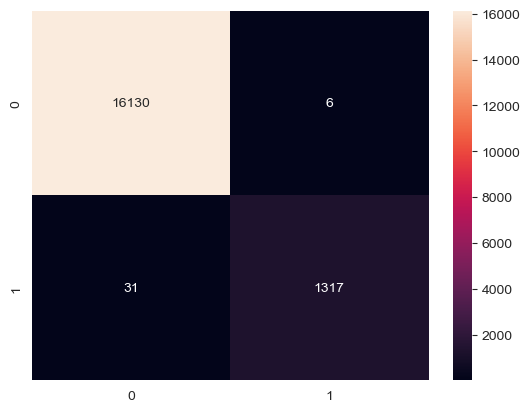

In [107]:
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt="d")
plt.show()

In [108]:
# feature importance
feat_imp_df = pd.DataFrame({
    "feature": X_train.columns.tolist(),
    "importance": cbc_model.feature_importances_
})
feat_imp_df.sort_values(by="importance", ascending=False)

,feature,importance
27,estimated_diff,51.865433
26,deliver_diff,46.410859
19,order_purchase_hour,0.438108
4,product_id,0.144681
5,seller_id,0.114041
2,customer_city,0.110685
18,order_purchase_dayofweek,0.095159
23,order_approved_dayofweek,0.075646
6,price,0.071547
3,customer_state,0.066618


In [109]:
cbc_model_full = cb.CatBoostClassifier(
    class_weights=np.sqrt(compute_class_weight('balanced', classes = y_train.unique(), y=y_train)),
    cat_features=cat_cols,
    eval_metric='Accuracy',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=200,
    verbose=100,
    random_seed=42,
)
cbc_model_full.fit(X, y)

Learning rate set to 0.026362
0:	learn: 0.9475029	total: 25.3ms	remaining: 25.3s
100:	learn: 0.9879303	total: 3.71s	remaining: 33s
200:	learn: 0.9912787	total: 6.77s	remaining: 26.9s
300:	learn: 0.9929163	total: 9.34s	remaining: 21.7s
400:	learn: 0.9938379	total: 11.9s	remaining: 17.8s
500:	learn: 0.9946737	total: 14.5s	remaining: 14.5s
600:	learn: 0.9952166	total: 17.2s	remaining: 11.4s
700:	learn: 0.9957883	total: 19.9s	remaining: 8.48s
800:	learn: 0.9961345	total: 22.5s	remaining: 5.59s
900:	learn: 0.9964037	total: 25.2s	remaining: 2.77s
999:	learn: 0.9967884	total: 27.8s	remaining: 0us


## Submissions

In [110]:
test_final_df = test_df.copy()
test_final_df = create_feature(test_final_df)

In [111]:
test_final_df

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_estimated_delivery_date,order_delivered_timestamp,order_purchase_month,order_purchase_day,order_purchase_dayofweek,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,deliver_diff,estimated_diff,season,product_volume,product_weight_ratio
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,1,credit_card,2,155.77,toys,50.0,16.0,5.0,11.0,2017-12-11,2017-12-05 00:10:05,11,18,5,12,46,11.0,18.0,5.0,12.0,46,16.0,22,Fall,880.0,0.056818
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,1,credit_card,1,4.07,electronics,200.0,21.0,7.0,14.0,2018-07-26,2018-06-28 19:56:24,6,2,5,17,22,6.0,2.0,5.0,20.0,22,26.0,53,Summer,2058.0,0.097182
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,1,wallet,1,381.59,furniture_decor,1000.0,100.0,5.0,20.0,2018-01-31,2018-01-15 19:15:09,1,8,0,11,2,1.0,9.0,1.0,7.0,2,7.0,22,Winter,10000.0,0.100000
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,1,credit_card,3,14.76,toys,8950.0,40.0,30.0,40.0,2017-03-31,2017-03-16 17:17:50,3,10,4,10,10,3.0,10.0,4.0,10.0,10,6.0,20,Spring,48000.0,0.186458
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,1,wallet,1,284.09,toys,2301.0,32.0,35.0,34.0,2018-01-10,2018-01-11 19:34:07,12,2,5,10,48,12.0,5.0,1.0,4.0,49,40.0,38,Winter,38080.0,0.060425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,Dw3aCTFf4Q4G,2018-08-24 11:54:56,2018-08-24 12:05:22,26160,guarulhos,SP,wr6barwyoaIE,XURInBuULfIO,99.25,37.66,1,credit_card,1,209.51,toys,200.0,16.0,28.0,11.0,2018-09-05,2018-08-28 16:19:26,8,24,4,11,34,8.0,24.0,4.0,12.0,34,4.0,11,Summer,4928.0,0.040584
38275,Tjiw9bj8HtLr,JmHJqJvpVcJs,2017-03-25 20:39:11,2017-03-25 20:50:17,39628,rio de janeiro,RJ,sPZVXBD9lf3e,wR4cqCClYDyY,86.32,40.98,1,credit_card,2,323.31,toys,5150.0,22.0,3.0,22.0,2017-04-18,2017-03-31 14:12:21,3,25,5,20,12,3.0,25.0,5.0,20.0,12,5.0,23,Spring,1452.0,3.546832
38276,mCPofb7A1aTq,ro5DikwWCC3j,2018-08-16 13:39:30,2018-08-17 03:31:06,89284,santana de parnaiba,SP,Th6SHMsyTOMH,Gp2lLacVPwug,104.45,30.24,1,wallet,1,170.71,toys,430.0,21.0,11.0,17.0,2018-08-22,2018-08-23 02:17:57,8,16,3,13,33,8.0,17.0,4.0,3.0,33,6.0,5,Summer,3927.0,0.109498
38277,scVuqN10zbgb,R25nE2rl77AU,2018-06-27 13:17:05,2018-06-28 08:50:58,60867,sao paulo,SP,PyjlDSHRGdSt,al4fWZ5NFQzG,223.87,74.75,1,credit_card,10,100.65,toys,1850.0,24.0,36.0,23.0,2018-07-20,2018-07-12 23:19:45,6,27,2,13,26,6.0,28.0,3.0,8.0,26,15.0,22,Summer,19872.0,0.093096


In [113]:
test_final_df = test_final_df.loc[:, X.columns.tolist()]
test_final_df.loc[test_final_df.product_category_name.isnull(), "product_category_name"] = "unknown"
test_final_df.head()

,order_purchase_timestamp,order_approved_at,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_purchase_month,order_purchase_day,order_purchase_dayofweek,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,deliver_diff,estimated_diff,season,product_volume,product_weight_ratio
0,2017-11-18 12:29:57,2017-11-18 12:46:08,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,credit_card,2,155.77,toys,50.0,16.0,5.0,11.0,11,18,5,12,46,11.0,18.0,5.0,12.0,46,16.0,22,Fall,880.0,0.056818
1,2018-06-02 17:13:12,2018-06-02 20:12:23,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,credit_card,1,4.07,electronics,200.0,21.0,7.0,14.0,6,2,5,17,22,6.0,2.0,5.0,20.0,22,26.0,53,Summer,2058.0,0.097182
2,2018-01-08 11:01:30,2018-01-09 07:24:03,campinas,SP,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,wallet,1,381.59,furniture_decor,1000.0,100.0,5.0,20.0,1,8,0,11,2,1.0,9.0,1.0,7.0,2,7.0,22,Winter,10000.0,0.100000
3,2017-03-10 10:24:46,2017-03-10 10:24:46,santana de parnaiba,SP,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,credit_card,3,14.76,toys,8950.0,40.0,30.0,40.0,3,10,4,10,10,3.0,10.0,4.0,10.0,10,6.0,20,Spring,48000.0,0.186458
4,2017-12-02 10:04:07,2017-12-05 04:13:30,aripuana,MT,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,wallet,1,284.09,toys,2301.0,32.0,35.0,34.0,12,2,5,10,48,12.0,5.0,1.0,4.0,49,40.0,38,Winter,38080.0,0.060425


In [114]:
test_final_df.isnull().sum()

order_purchase_timestamp      0
order_approved_at             7
customer_city                 0
customer_state                0
product_id                    0
seller_id                     0
price                         0
shipping_charges              0
payment_type                  0
payment_installments          0
payment_value                 0
product_category_name         0
product_weight_g             10
product_length_cm            10
product_height_cm            10
product_width_cm             10
order_purchase_month          0
order_purchase_day            0
order_purchase_dayofweek      0
order_purchase_hour           0
order_purchase_week           0
order_approved_month          7
order_approved_day            7
order_approved_dayofweek      7
order_approved_hour           7
order_approved_week           7
deliver_diff                874
estimated_diff                0
season                        0
product_volume               10
product_weight_ratio         10
dtype: i

In [115]:
test_final_df.loc[test_final_df.order_approved_at.isnull(), "order_approved_at"].index

Int64Index([309, 4699, 16372, 21613, 28627, 30628, 36653], dtype='int64')

In [116]:
test_final_df.loc[test_final_df.order_approved_at.isnull(), "order_approved_at"] = \
    test_final_df.loc[test_final_df.order_approved_at.isnull(), "order_purchase_timestamp"] + \
    (test_final_df.order_approved_at - test_final_df.order_purchase_timestamp).mean()

In [117]:
test_final_df.loc[[309, 4699, 16372, 21613, 28627, 30628, 36653], :]

,order_purchase_timestamp,order_approved_at,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_purchase_month,order_purchase_day,order_purchase_dayofweek,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,deliver_diff,estimated_diff,season,product_volume,product_weight_ratio
309,2017-02-18 22:49:19,2017-02-19 09:17:45.739940426,rio de janeiro,RJ,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,wallet,1,106.56,telephony,250.0,18.0,3.0,28.0,2,18,5,22,7,NaN,NaN,NaN,NaN,<NA>,11.0,30,Winter,1512.0,0.165344
4699,2017-02-18 12:45:31,2017-02-18 23:13:57.739940426,novo hamburgo,RS,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,wallet,1,152.21,toys,1008.0,33.0,14.0,26.0,2,18,5,12,7,NaN,NaN,NaN,NaN,<NA>,11.0,30,Winter,12012.0,0.083916
16372,2017-02-18 22:49:19,2017-02-19 09:17:45.739940426,rio de janeiro,RJ,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,wallet,1,106.56,telephony,250.0,18.0,3.0,28.0,2,18,5,22,7,NaN,NaN,NaN,NaN,<NA>,11.0,30,Winter,1512.0,0.165344
21613,2017-02-19 01:28:47,2017-02-19 11:57:13.739940426,sao paulo,SP,KsJ0qytYsZlU,2a07LobkzHUx,434.99,83.60,wallet,1,93.52,toys,1700.0,33.0,8.0,23.0,2,19,6,1,7,NaN,NaN,NaN,NaN,<NA>,11.0,35,Winter,6072.0,0.279974
28627,2017-01-19 12:48:08,2017-01-19 23:16:34.739940426,santos,SP,qJJWuXhXxynp,3cqSxyYyqpx6,475.00,2.46,wallet,1,67.08,toys,700.0,26.0,16.0,21.0,1,19,3,12,3,NaN,NaN,NaN,NaN,<NA>,11.0,40,Winter,8736.0,0.080128
30628,2017-02-18 17:15:03,2017-02-19 03:43:29.739940426,sao jose de ribamar,MA,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,wallet,1,258.08,cool_stuff,1200.0,42.0,25.0,15.0,2,18,5,17,7,NaN,NaN,NaN,NaN,<NA>,13.0,40,Winter,15750.0,0.076190
36653,2017-02-18 13:29:47,2017-02-18 23:58:13.739940426,sao paulo,SP,3CttGRrxTrK5,u3MhLPomw5UN,111.27,75.01,wallet,1,172.33,toys,3100.0,28.0,28.0,50.0,2,18,5,13,7,NaN,NaN,NaN,NaN,<NA>,10.0,26,Winter,39200.0,0.079082


In [118]:
test_final_df.fillna(-1, inplace=True)
test_final_df.isnull().sum()

order_purchase_timestamp    0
order_approved_at           0
customer_city               0
customer_state              0
product_id                  0
seller_id                   0
price                       0
shipping_charges            0
payment_type                0
payment_installments        0
payment_value               0
product_category_name       0
product_weight_g            0
product_length_cm           0
product_height_cm           0
product_width_cm            0
order_purchase_month        0
order_purchase_day          0
order_purchase_dayofweek    0
order_purchase_hour         0
order_purchase_week         0
order_approved_month        0
order_approved_day          0
order_approved_dayofweek    0
order_approved_hour         0
order_approved_week         0
deliver_diff                0
estimated_diff              0
season                      0
product_volume              0
product_weight_ratio        0
dtype: int64

In [121]:
y_test_pred = cbc_model_full.predict(test_final_df)
y_test_pred[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0], dtype=int64)

In [122]:
submission_df = pd.DataFrame({
    "order_id": test_df.order_id,
    "is_late": y_test_pred
})
submission_df.head()

,order_id,is_late
0,u6rPMRAYIGig,0
1,ohY8f4FEbX19,0
2,I28liQek73i2,0
3,bBG1T89mlY8W,0
4,CYxJJSQS8Lbo,1


In [123]:
submission_df.is_late.value_counts()

0    35217
1     3062
Name: is_late, dtype: int64

In [124]:
submission_df.to_csv("submissions/submission_4_1.csv", index=False)